**Imports**

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

**Load datasets**

In [104]:
train = pd.read_csv('train.csv')
store = pd.read_csv('store.csv')

/tmp/ipykernel_3923/1671973049.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


**Quick inspection**

In [105]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [106]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [107]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [108]:
store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

**Merge datasets**

In [109]:
df = pd.merge(train, store, on='Store', how='left')

In [110]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


**Data inspection**

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [112]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


**Convert date column**

In [113]:
df['Date'] = pd.to_datetime(df['Date'])


In [114]:
print(df['Date'].dtype)

datetime64[ns]


**Missing value handling**

**CompetitionDistance**

In [115]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)

/tmp/ipykernel_3923/394802485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)


**CompetitionOpenSinceMonth**


In [116]:
df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)

/tmp/ipykernel_3923/36865109.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)


**CompetitionOpenSinceYear**

In [117]:
df['CompetitionOpenSinceYear'].fillna(0, inplace=True)

/tmp/ipykernel_3923/3465246726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionOpenSinceYear'].fillna(0, inplace=True)


**Promo2SinceWeek**

In [118]:
df['Promo2SinceWeek'].fillna(0, inplace=True)

/tmp/ipykernel_3923/1847494158.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Promo2SinceWeek'].fillna(0, inplace=True)


**Promo2SinceYear**

In [119]:
df['Promo2SinceYear'].fillna(0, inplace=True)

/tmp/ipykernel_3923/2155061422.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Promo2SinceYear'].fillna(0, inplace=True)


**PromoInterval**

In [120]:
df['PromoInterval'].fillna('None', inplace=True)

/tmp/ipykernel_3923/2545337844.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PromoInterval'].fillna('None', inplace=True)


**Recheck nulls**

In [121]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


**Remove closed stores**

In [122]:
df = df[df['Open'] == 1]

**Remove zero sales**

In [123]:
df = df[df['Sales'] > 0]

**Duplicate check**

In [124]:
df.duplicated().sum()

np.int64(0)

**Year extraction , Month extraction, Month name, Day extraction, Week of year**

In [125]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

**Weekend flag, Sales per customer, Promo status label, Holiday status**

In [126]:
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x in [6,7] else 0)
df['SalesPerCustomer'] = df['Sales'] / df['Customers']
df['PromoStatus'] = df['Promo'].map({0:'No Promo', 1:'Promo'})
df['HolidayStatus'] = df['StateHoliday'].apply(lambda x: 'Holiday' if x != '0' else 'Non-Holiday')


**Store type renaming, Assortment renaming**

In [127]:
df['StoreType'] = df['StoreType'].replace({
    'a':'Type A',
    'b':'Type B',
    'c':'Type C',
    'd':'Type D'
})



df['Assortment'] = df['Assortment'].replace({
    'a':'Basic',
    'b':'Extra',
    'c':'Extended'
})

**(KPI)Total Revenue, Total Customers, Average Daily Sales, Average Sales Per Customer, Total Stores**

In [128]:
print(df['Sales'].sum())
print(df['Customers'].sum())
print(df['Sales'].mean())
print(df['SalesPerCustomer'].mean())
print(df['Store'].nunique())

5873180623
644041747
6955.959133664481
9.493641491077096
1115


In [129]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoInterval,Year,Month,MonthName,Day,WeekOfYear,IsWeekend,SalesPerCustomer,PromoStatus,HolidayStatus
0,1,5,2015-07-31,5263,555,1,1,0,1,Type C,...,None,2015,7,July,31,31,0,9.482883,Promo,Non-Holiday
1,2,5,2015-07-31,6064,625,1,1,0,1,Type A,...,"Jan,Apr,Jul,Oct",2015,7,July,31,31,0,9.702400,Promo,Non-Holiday
2,3,5,2015-07-31,8314,821,1,1,0,1,Type A,...,"Jan,Apr,Jul,Oct",2015,7,July,31,31,0,10.126675,Promo,Non-Holiday
3,4,5,2015-07-31,13995,1498,1,1,0,1,Type C,...,None,2015,7,July,31,31,0,9.342457,Promo,Non-Holiday
4,5,5,2015-07-31,4822,559,1,1,0,1,Type A,...,None,2015,7,July,31,31,0,8.626118,Promo,Non-Holiday


**EDA 1 — Monthly Sales Trend**

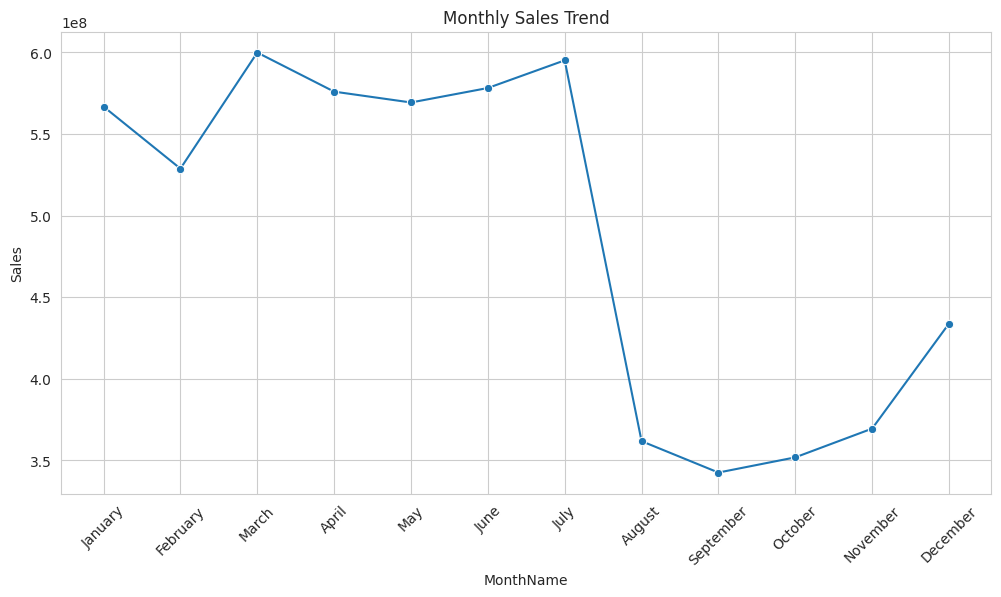

In [130]:
monthly_sales = df.groupby('MonthName')['Sales'].sum().reset_index()

#Correct Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales['MonthName'] = pd.Categorical(
    monthly_sales['MonthName'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('MonthName')

#plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='MonthName', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()


**EDA 2 — Yearly Sales Trend**

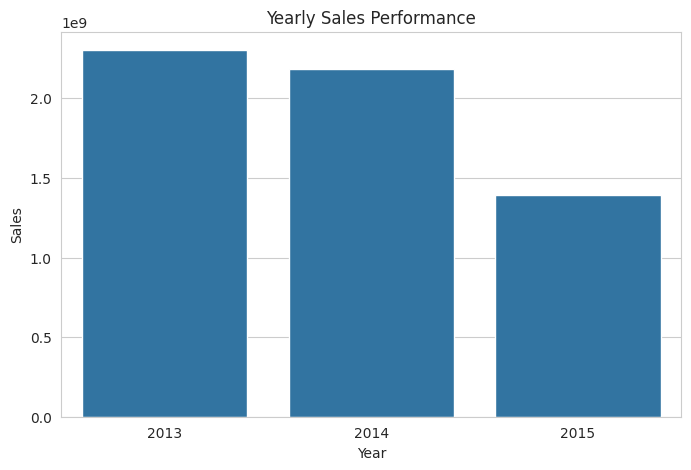

In [131]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_sales, x='Year', y='Sales')
plt.title('Yearly Sales Performance')
plt.show()

**EDA 3 — Promo vs Non-Promo Sales**

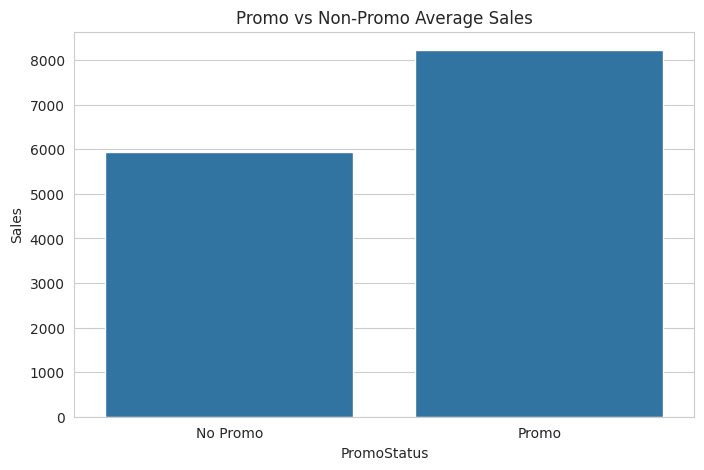

In [132]:
promo_sales = df.groupby('PromoStatus')['Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=promo_sales, x='PromoStatus', y='Sales')
plt.title('Promo vs Non-Promo Average Sales')
plt.show()

**EDA 4 — Holiday vs Non-Holiday Sales**

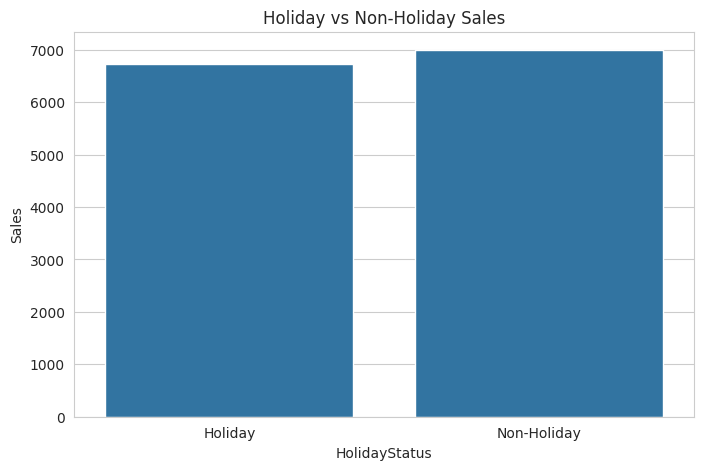

In [133]:
holiday_sales = df.groupby('HolidayStatus')['Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=holiday_sales, x='HolidayStatus', y='Sales')
plt.title('Holiday vs Non-Holiday Sales')
plt.show()

**EDA 5 — Top Performing Stores**

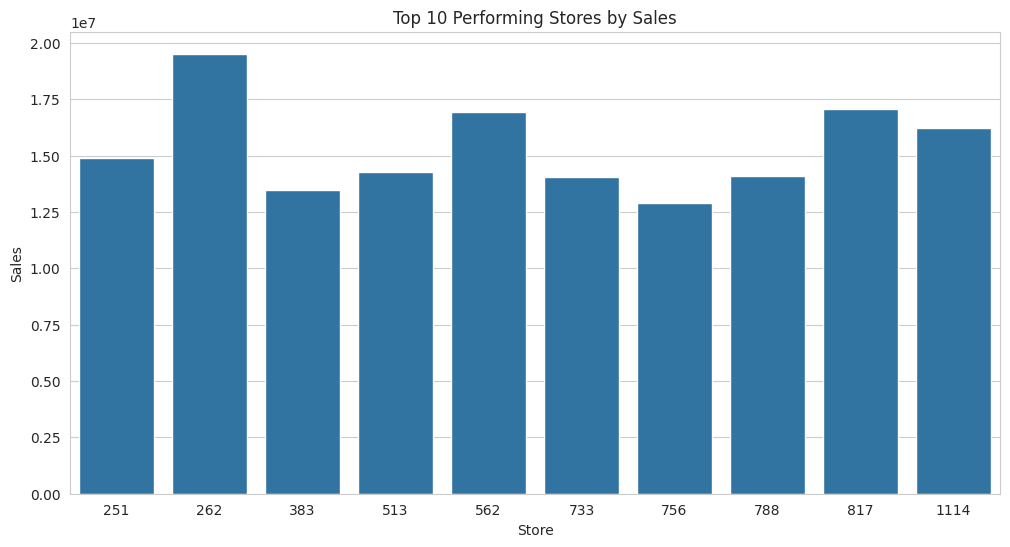

In [134]:
top_stores = df.groupby('Store')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_stores, x='Store', y='Sales')
plt.title('Top 10 Performing Stores by Sales')
plt.show()

**EDA 6 — Store Type Performance**

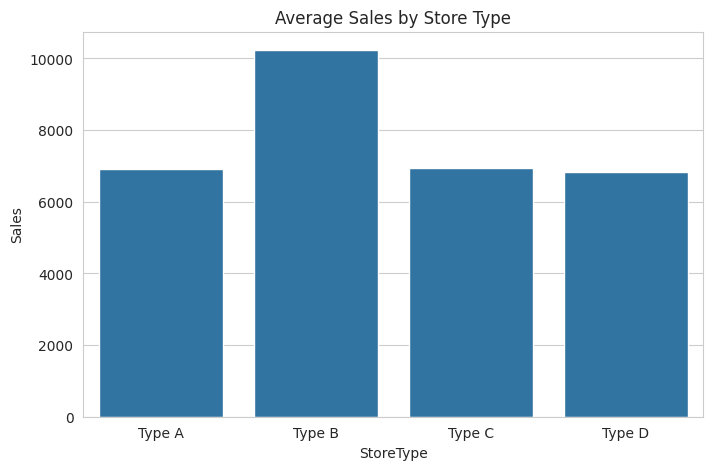

In [135]:
store_type_sales = df.groupby('StoreType')['Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=store_type_sales, x='StoreType', y='Sales')
plt.title('Average Sales by Store Type')
plt.show()

**EDA 7 — Customer Traffic Trend**

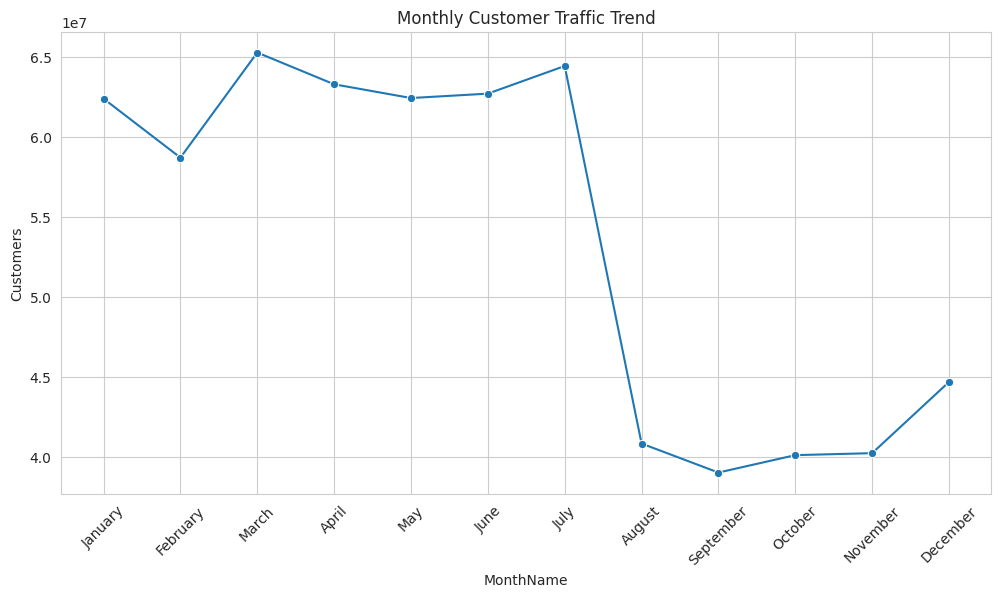

In [136]:
monthly_customers = df.groupby('MonthName')['Customers'].sum().reset_index()

monthly_customers['MonthName'] = pd.Categorical(
    monthly_customers['MonthName'],
    categories=month_order,
    ordered=True
)

monthly_customers = monthly_customers.sort_values('MonthName')

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_customers, x='MonthName', y='Customers', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Customer Traffic Trend')
plt.show()

**EDA 8 — Weekend vs Weekday Sales**

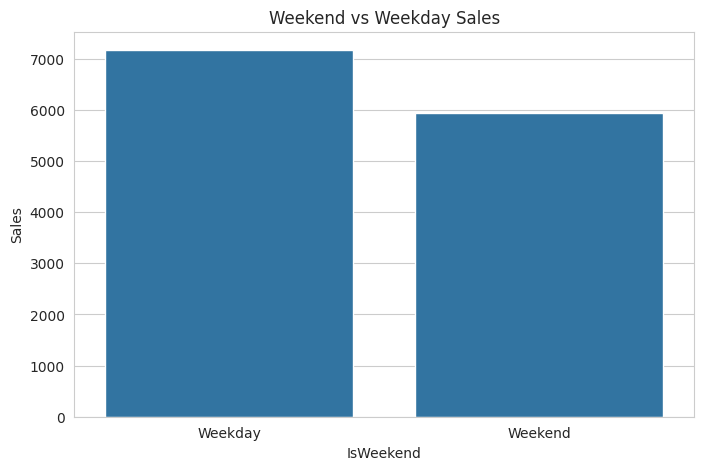

In [137]:
weekend_sales = df.groupby('IsWeekend')['Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weekend_sales, x='IsWeekend', y='Sales')
plt.title('Weekend vs Weekday Sales')
plt.xticks([0,1], ['Weekday','Weekend'])
plt.show()

**EDA 9 — Competition Impact**

/tmp/ipykernel_3923/3968812460.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  competition_sales = df.groupby('CompetitionGroup')['Sales'].mean().reset_index()


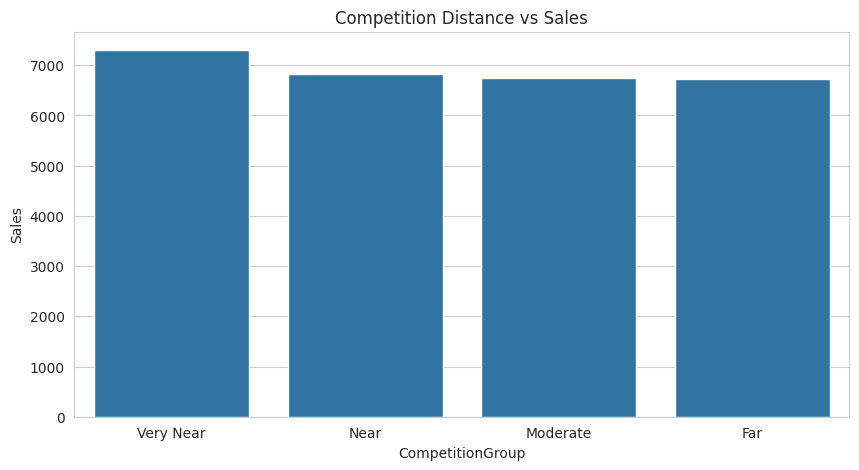

In [138]:
df['CompetitionGroup'] = pd.cut(
    df['CompetitionDistance'],
    bins=[0,1000,5000,10000,20000],
    labels=['Very Near','Near','Moderate','Far']
)

competition_sales = df.groupby('CompetitionGroup')['Sales'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=competition_sales, x='CompetitionGroup', y='Sales')
plt.title('Competition Distance vs Sales')
plt.show()

**EDA 10 — Assortment Performance**

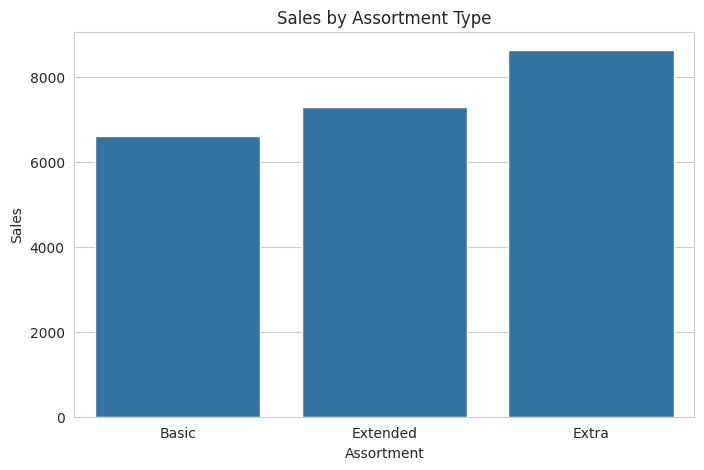

In [139]:
assortment_sales = df.groupby('Assortment')['Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=assortment_sales, x='Assortment', y='Sales')
plt.title('Sales by Assortment Type')
plt.show()

**Business Insights Extraction**

In [140]:
best_month = monthly_sales.sort_values(by='Sales', ascending=False).head(1)
best_month

,MonthName,Sales
7,March,599831906


In [141]:
lowest_month = monthly_sales.sort_values(by='Sales').head(1)
lowest_month

,MonthName,Sales
11,September,342570131


In [142]:
store_type_sales.sort_values(by='Sales', ascending=False)

,StoreType,Sales
1,Type B,10233.380141
2,Type C,6933.126425
0,Type A,6925.697986
3,Type D,6822.300064


In [143]:
promo_sales

,PromoStatus,Sales
0,No Promo,5929.826183
1,Promo,8228.739731


In [144]:
holiday_sales

,HolidayStatus,Sales
0,Holiday,6719.642405
1,Non-Holiday,6992.483936


In [145]:
top_stores.head(1)

,Store,Sales
261,262,19516842


In [146]:
weekend_sales

,IsWeekend,Sales
0,0,7172.903208
1,1,5932.264337


In [147]:
competition_sales

,CompetitionGroup,Sales
0,Very Near,7302.468962
1,Near,6827.418000
2,Moderate,6742.643204
3,Far,6733.295124


**SQL Part**

In [148]:
import sqlite3
conn = sqlite3.connect('rossmann.db')
df.to_sql('sales_data', conn, if_exists='replace', index=False)

844338

In [149]:
pd.read_sql("SELECT * FROM sales_data LIMIT 5;", conn)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,MonthName,Day,WeekOfYear,IsWeekend,SalesPerCustomer,PromoStatus,HolidayStatus,CompetitionGroup
0,1,5,2015-07-31 00:00:00,5263,555,1,1,0,1,Type C,...,2015,7,July,31,31,0,9.482883,Promo,Non-Holiday,Near
1,2,5,2015-07-31 00:00:00,6064,625,1,1,0,1,Type A,...,2015,7,July,31,31,0,9.702400,Promo,Non-Holiday,Very Near
2,3,5,2015-07-31 00:00:00,8314,821,1,1,0,1,Type A,...,2015,7,July,31,31,0,10.126675,Promo,Non-Holiday,Far
3,4,5,2015-07-31 00:00:00,13995,1498,1,1,0,1,Type C,...,2015,7,July,31,31,0,9.342457,Promo,Non-Holiday,Very Near
4,5,5,2015-07-31 00:00:00,4822,559,1,1,0,1,Type A,...,2015,7,July,31,31,0,8.626118,Promo,Non-Holiday,None


**Query 1 — Top 10 Stores**

In [150]:
query1 = """
SELECT Store, SUM(Sales) AS TotalSales
FROM sales_data
GROUP BY Store
ORDER BY TotalSales DESC
LIMIT 10;
"""

pd.read_sql(query1, conn)

,Store,TotalSales
0,262,19516842
1,817,17057867
2,562,16927322
3,1114,16202585
4,251,14896870
5,513,14252406
6,788,14082141
7,733,14067158
8,383,13489879
9,756,12911782


**Query 2 — Promo Effectiveness**

In [151]:
query2 = """
SELECT PromoStatus, AVG(Sales) AS AvgSales
FROM sales_data
GROUP BY PromoStatus;
"""

pd.read_sql(query2, conn)

,PromoStatus,AvgSales
0,No Promo,5929.826183
1,Promo,8228.739731


**Query 3 — Store Type Performance**

In [152]:
query3 = """
SELECT StoreType, AVG(Sales) AS AvgSales
FROM sales_data
GROUP BY StoreType
ORDER BY AvgSales DESC;
"""

pd.read_sql(query3, conn)

,StoreType,AvgSales
0,Type B,10233.380141
1,Type C,6933.126425
2,Type A,6925.697986
3,Type D,6822.300064


**Query 4 — Holiday Impact**

In [153]:
query4 = """
SELECT HolidayStatus, AVG(Sales) AS AvgSales
FROM sales_data
GROUP BY HolidayStatus;
"""

pd.read_sql(query4, conn)

,HolidayStatus,AvgSales
0,Holiday,6719.642405
1,Non-Holiday,6992.483936


**Query 5 — Monthly Revenue**

In [154]:
query5 = """
SELECT MonthName, SUM(Sales) AS TotalSales
FROM sales_data
GROUP BY MonthName
ORDER BY TotalSales DESC;
"""

pd.read_sql(query5, conn)

,MonthName,TotalSales
0,March,599831906
1,July,595059205
2,June,578112775
3,April,575895295
4,May,569248217
5,January,566728724
6,February,528734410
7,December,433831153
8,November,369498877
9,August,361791202


**Export Clean Data for Power BI**

In [155]:
df.to_csv('rossmann_cleaned_data.csv', index=False)